In [28]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import MinMaxScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [29]:
df = pd.read_csv("spambase_csv.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [30]:
df = pd.read_csv("spambase_csv.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [31]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [32]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nInformation")
df.info()

Shape : (4601, 58)

Columns
Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_tabl

In [33]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [34]:
print(df.isnull().sum())

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [35]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 391


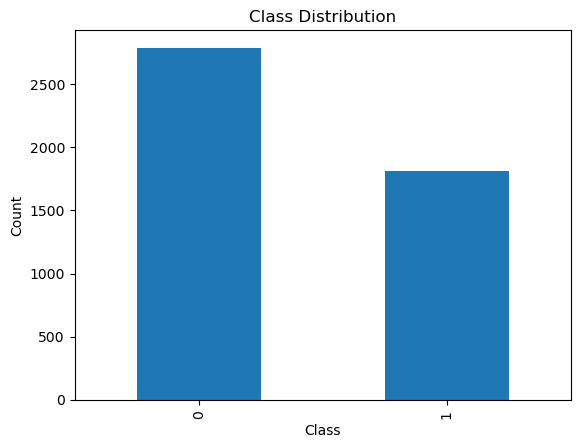

In [36]:
df["class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

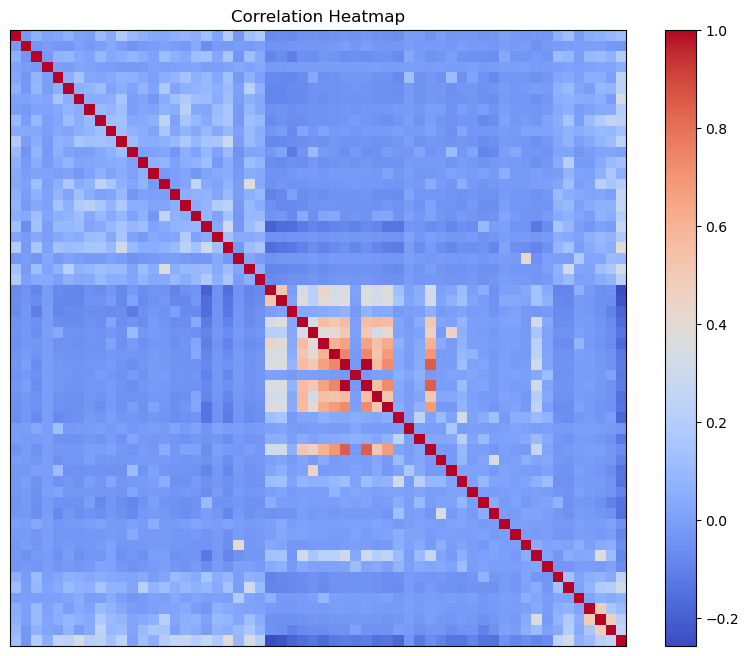

In [37]:
plt.figure(figsize=(10,8))

corr = df.corr()

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks([])
plt.yticks([])

plt.title("Correlation Heatmap")

plt.show()

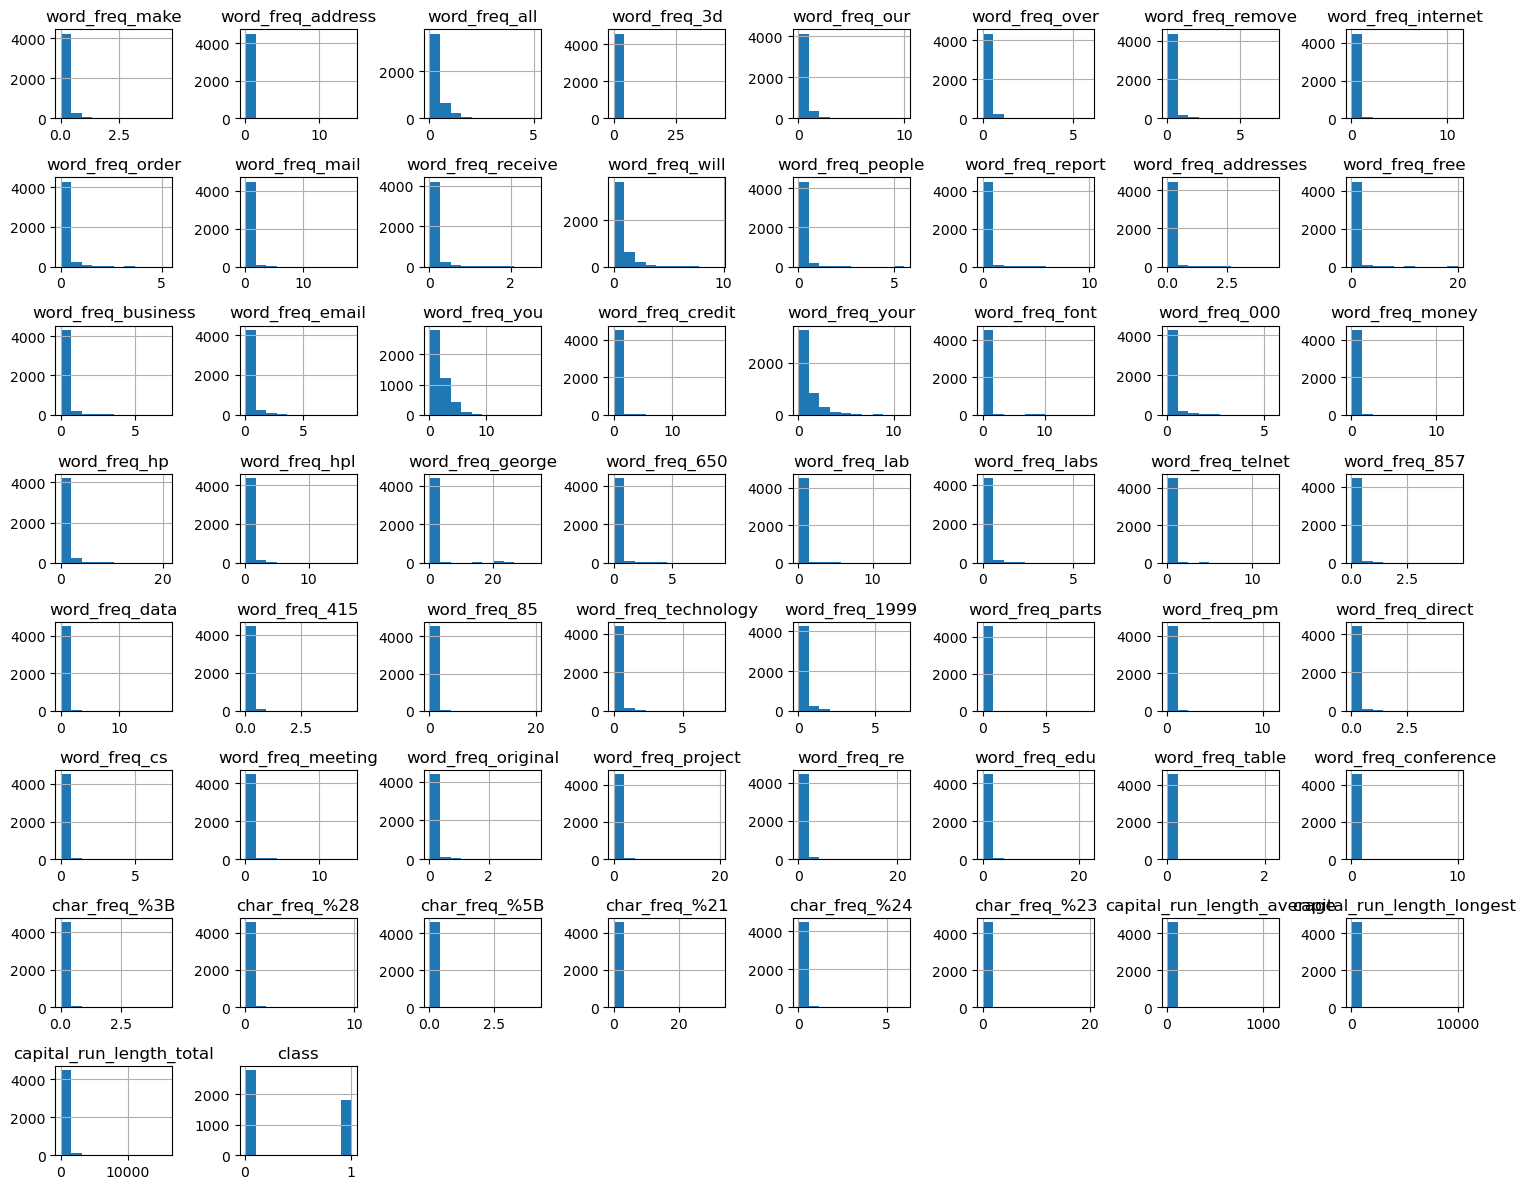

In [38]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

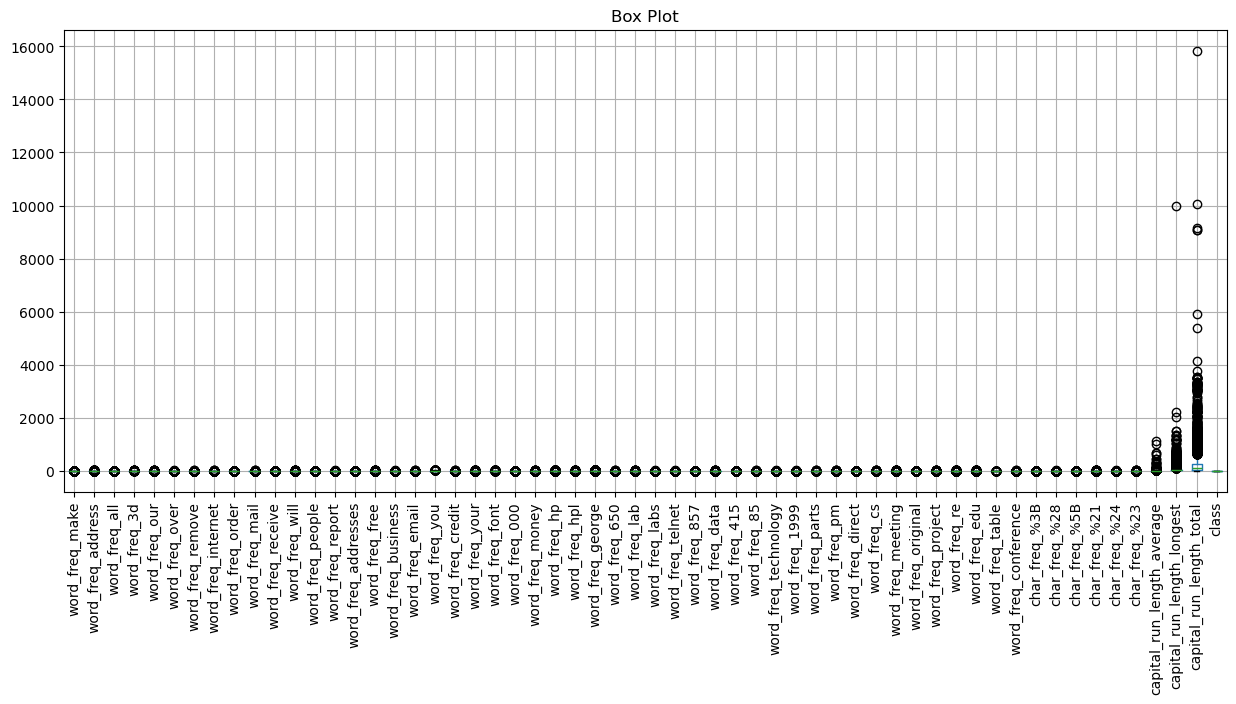

In [39]:
plt.figure(figsize=(15,6))

df.boxplot(rot=90)

plt.title("Box Plot")

plt.show()

In [40]:
X = df.drop("class", axis=1)
y = df["class"]

In [41]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

print("Features Normalized")

Features Normalized


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 3680
Testing Samples : 921


In [43]:
gnb = GaussianNB()

start = time.time()

gnb.fit(X_train, y_train)

train_time_gnb = time.time() - start

start = time.time()

y_pred_gnb = gnb.predict(X_test)

prediction_time_gnb = time.time() - start

In [44]:
mnb = MultinomialNB()

start = time.time()

mnb.fit(X_train, y_train)

train_time_mnb = time.time() - start

start = time.time()

y_pred_mnb = mnb.predict(X_test)

prediction_time_mnb = time.time() - start

In [45]:
bnb = BernoulliNB()

start = time.time()

bnb.fit(X_train, y_train)

train_time_bnb = time.time() - start

start = time.time()

y_pred_bnb = bnb.predict(X_test)

prediction_time_bnb = time.time() - start

In [46]:
knn = KNeighborsClassifier(n_neighbors=5)

start = time.time()

knn.fit(X_train, y_train)

train_time_knn = time.time() - start

start = time.time()

y_pred_knn = knn.predict(X_test)

prediction_time_knn = time.time() - start

In [47]:
def evaluate(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_pred)

    return accuracy, precision, recall, f1, roc

In [48]:
g = evaluate(y_test, y_pred_gnb)
m = evaluate(y_test, y_pred_mnb)
b = evaluate(y_test, y_pred_bnb)

nb_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Gaussian": g,
    "Multinomial": m,
    "Bernoulli": b
})

nb_results

,Metric,Gaussian,Multinomial,Bernoulli
0,Accuracy,0.821933,0.871878,0.880565
1,Precision,0.723320,0.950331,0.904624
2,Recall,0.938462,0.735897,0.802564
3,F1,0.816964,0.829480,0.850543
4,ROC-AUC,0.837404,0.853824,0.870209


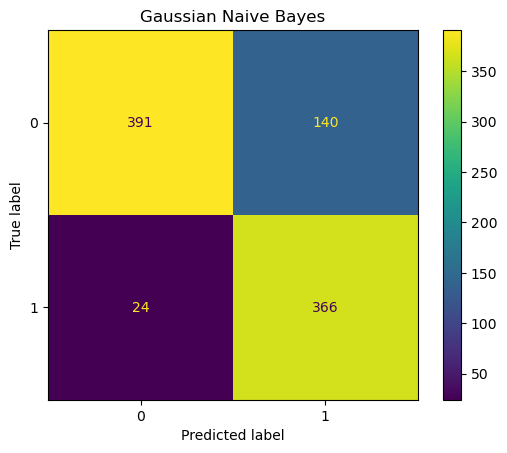

In [49]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gnb)

plt.title("Gaussian Naive Bayes")

plt.show()

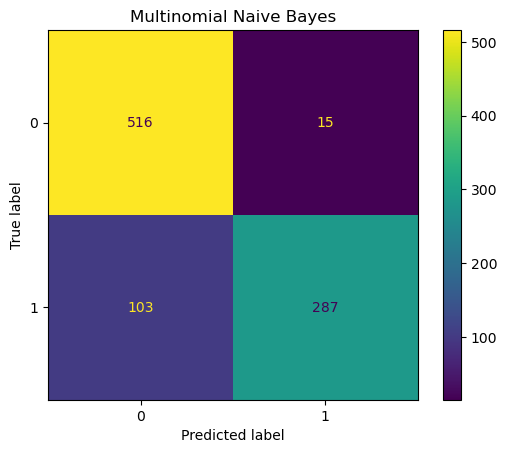

In [50]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mnb)

plt.title("Multinomial Naive Bayes")

plt.show()

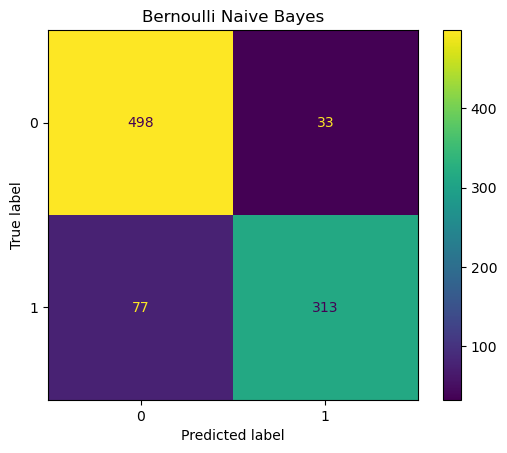

In [51]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bnb)

plt.title("Bernoulli Naive Bayes")

plt.show()

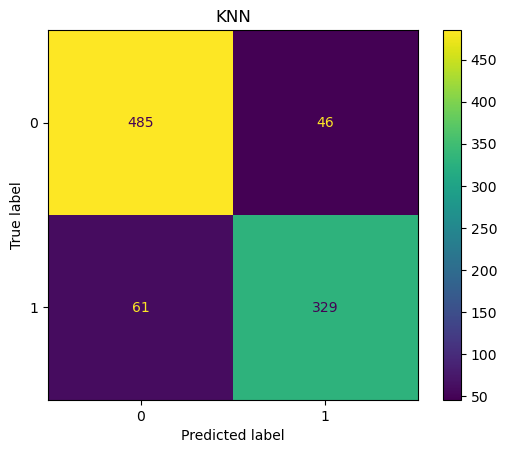

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)

plt.title("KNN")

plt.show()

In [53]:
k_values = [1, 3, 5, 7, 9, 11]

results = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([k, accuracy, precision, recall, f1])

knn_table = pd.DataFrame(
    results,
    columns=["k", "Accuracy", "Precision", "Recall", "F1"]
)

knn_table

,k,Accuracy,Precision,Recall,F1
0,1,0.881650,0.850374,0.874359,0.862200
1,3,0.880565,0.872340,0.841026,0.856397
2,5,0.883822,0.877333,0.843590,0.860131
3,7,0.884908,0.879679,0.843590,0.861257
4,9,0.877307,0.887955,0.812821,0.848728
5,11,0.882736,0.896067,0.817949,0.855228


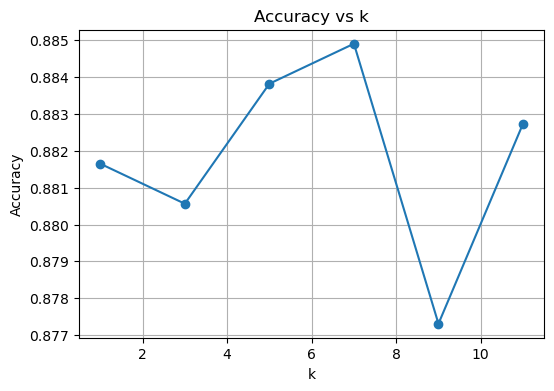

In [54]:
plt.figure(figsize=(6,4))

plt.plot(
    knn_table["k"],
    knn_table["Accuracy"],
    marker="o"
)

plt.title("Accuracy vs k")

plt.xlabel("k")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [55]:
parameters = {
    "n_neighbors": [1, 3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "kd_tree", "ball_tree"]
}

start = time.time()

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    parameters,
    cv=5
)

grid_search.fit(X_train, y_train)

grid_time = time.time() - start

print("Best Parameters")
print(grid_search.best_params_)

print("\nBest CV Score")
print(grid_search.best_score_)

Best Parameters
{'algorithm': 'auto', 'n_neighbors': 5, 'weights': 'distance'}

Best CV Score
0.9141304347826086


In [56]:
random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=parameters,
    n_iter=10,
    cv=5,
    random_state=42
)

start = time.time()

random_search.fit(X_train, y_train)

random_time = time.time() - start

print("Best Parameters")
print(random_search.best_params_)

print("\nBest CV Score")
print(random_search.best_score_)

Best Parameters
{'weights': 'distance', 'n_neighbors': 5, 'algorithm': 'kd_tree'}

Best CV Score
0.9141304347826086


In [57]:
search_result = pd.DataFrame({
    "Parameter": [
        "Best k",
        "Weights",
        "Algorithm",
        "CV Accuracy",
        "Execution Time"
    ],
    "GridSearchCV": [
        grid_search.best_params_["n_neighbors"],
        grid_search.best_params_["weights"],
        grid_search.best_params_["algorithm"],
        grid_search.best_score_,
        grid_time
    ],
    "RandomizedSearchCV": [
        random_search.best_params_["n_neighbors"],
        random_search.best_params_["weights"],
        random_search.best_params_["algorithm"],
        random_search.best_score_,
        random_time
    ]
})

search_result

,Parameter,GridSearchCV,RandomizedSearchCV
0,Best k,5,5
1,Weights,distance,distance
2,Algorithm,auto,kd_tree
3,CV Accuracy,0.91413,0.91413
4,Execution Time,28.398,9.394


In [58]:
algorithms = ["kd_tree", "ball_tree"]

tree_result = []

for algo in algorithms:

    model = KNeighborsClassifier(
        n_neighbors=5,
        algorithm=algo
    )

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    pred = model.predict(X_test)
    predict_time = time.time() - start

    accuracy = accuracy_score(y_test, pred)

    tree_result.append(
        [algo, accuracy, train_time, predict_time]
    )

tree_table = pd.DataFrame(
    tree_result,
    columns=[
        "Algorithm",
        "Accuracy",
        "Training Time",
        "Prediction Time"
    ]
)

tree_table

,Algorithm,Accuracy,Training Time,Prediction Time
0,kd_tree,0.883822,0.041,0.264
1,ball_tree,0.883822,0.020,0.229


In [59]:
nb_cv = cross_val_score(GaussianNB(), X, y, cv=5)

best_knn = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_["n_neighbors"],
    weights=grid_search.best_params_["weights"],
    algorithm=grid_search.best_params_["algorithm"]
)

knn_cv = cross_val_score(best_knn, X, y, cv=5)

cv_table = pd.DataFrame({
    "Fold":[1,2,3,4,5],
    "Naive Bayes":nb_cv,
    "Best KNN":knn_cv
})

cv_table

,Fold,Naive Bayes,Best KNN
0,1,0.851249,0.876221
1,2,0.866304,0.892391
2,3,0.854348,0.918478
3,4,0.843478,0.909783
4,5,0.695652,0.763043


In [60]:
average = pd.DataFrame({
    "Model":["Naive Bayes","Best KNN"],
    "Average Accuracy":[
        nb_cv.mean(),
        knn_cv.mean()
    ]
})

average

,Model,Average Accuracy
0,Naive Bayes,0.822206
1,Best KNN,0.871983


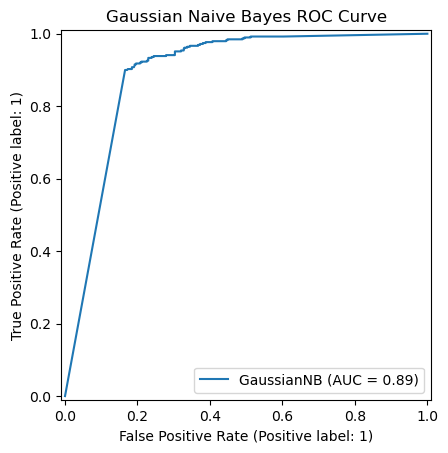

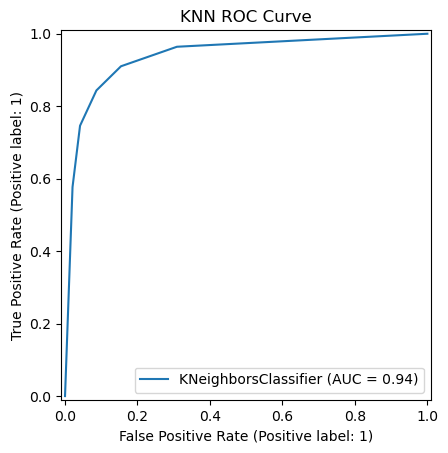

In [61]:
RocCurveDisplay.from_estimator(gnb, X_test, y_test)
plt.title("Gaussian Naive Bayes ROC Curve")
plt.show()

RocCurveDisplay.from_estimator(knn, X_test, y_test)
plt.title("KNN ROC Curve")
plt.show()

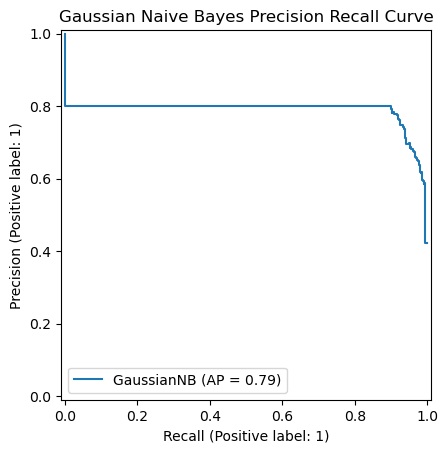

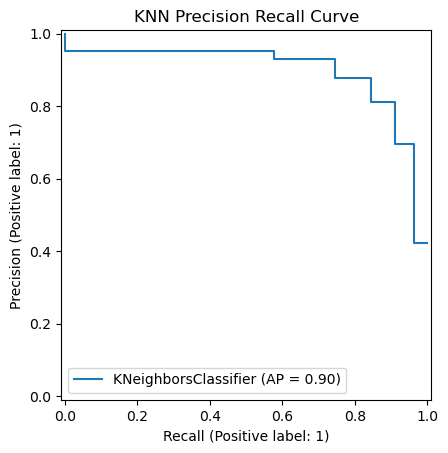

In [62]:
PrecisionRecallDisplay.from_estimator(gnb, X_test, y_test)
plt.title("Gaussian Naive Bayes Precision Recall Curve")
plt.show()

PrecisionRecallDisplay.from_estimator(knn, X_test, y_test)
plt.title("KNN Precision Recall Curve")
plt.show()

In [63]:
training = pd.DataFrame({
    "Algorithm":[
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB",
        "Best KNN"
    ],
    "Training Time":[
        train_time_gnb,
        train_time_mnb,
        train_time_bnb,
        train_time_knn
    ]
})

training

,Algorithm,Training Time
0,Gaussian NB,0.008
1,Multinomial NB,0.007
2,Bernoulli NB,0.012
3,Best KNN,0.002


In [64]:
prediction = pd.DataFrame({
    "Algorithm":[
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB",
        "Best KNN"
    ],
    "Prediction Time":[
        prediction_time_gnb,
        prediction_time_mnb,
        prediction_time_bnb,
        prediction_time_knn
    ]
})

prediction

,Algorithm,Prediction Time
0,Gaussian NB,0.002
1,Multinomial NB,0.001
2,Bernoulli NB,0.002
3,Best KNN,0.111


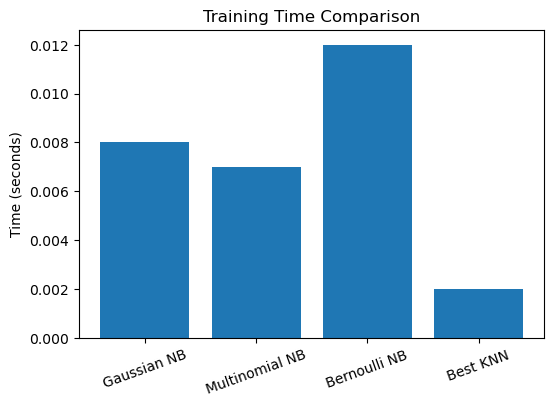

In [65]:
plt.figure(figsize=(6,4))

plt.bar(training["Algorithm"], training["Training Time"])

plt.title("Training Time Comparison")

plt.ylabel("Time (seconds)")

plt.xticks(rotation=20)

plt.show()

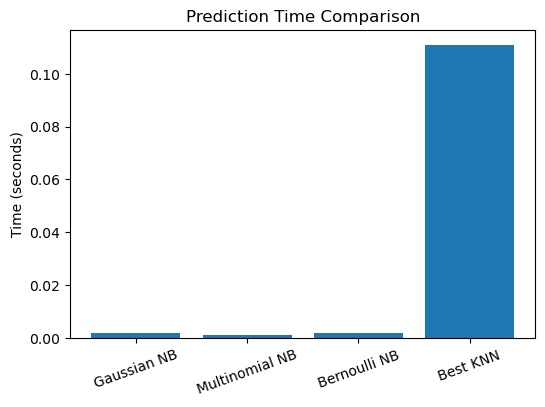

In [66]:
plt.figure(figsize=(6,4))

plt.bar(prediction["Algorithm"], prediction["Prediction Time"])

plt.title("Prediction Time Comparison")

plt.ylabel("Time (seconds)")

plt.xticks(rotation=20)

plt.show()

In [67]:
classifier = pd.DataFrame({
    "Classifier":[
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB",
        "KNN"
    ],
    "Accuracy":[
        g[0],
        m[0],
        b[0],
        evaluate(y_test, y_pred_knn)[0]
    ]
})

classifier

,Classifier,Accuracy
0,Gaussian NB,0.821933
1,Multinomial NB,0.871878
2,Bernoulli NB,0.880565
3,KNN,0.883822


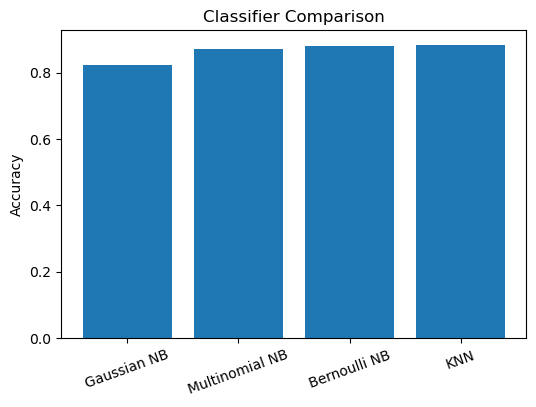

In [68]:
plt.figure(figsize=(6,4))

plt.bar(classifier["Classifier"], classifier["Accuracy"])

plt.title("Classifier Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()